# Simple Linear Regression

## Import Packages

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## Load Data From a CSV file

In [2]:
data = pd.read_csv('FuelConsumption.csv')
data

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


## Explore in datas

In [3]:
data.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


### choose special feature from datas

In [4]:
c_data = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
c_data

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1062,3.0,6,11.8,271
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


## Create histogram of datas for analysis 

array([[<Axes: title={'center': 'ENGINESIZE'}>,
        <Axes: title={'center': 'CYLINDERS'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_COMB'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

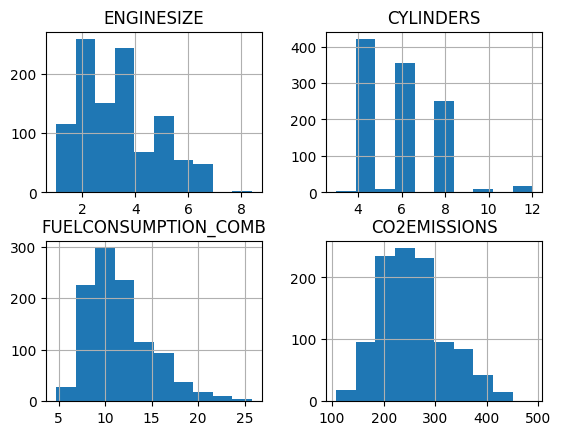

In [5]:
c_data.hist()

Text(0.5, 0, 'FUELCONSUMPTION_COMB')

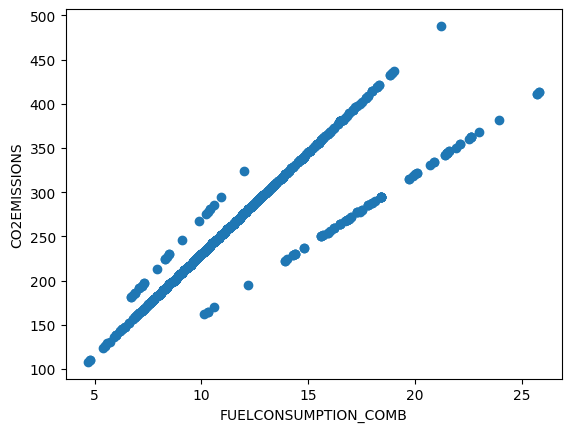

In [6]:
plt.scatter(c_data.FUELCONSUMPTION_COMB, c_data.CO2EMISSIONS)
plt.ylabel('CO2EMISSIONS')
plt.xlabel('FUELCONSUMPTION_COMB')

Text(0.5, 0, 'Engine Size')

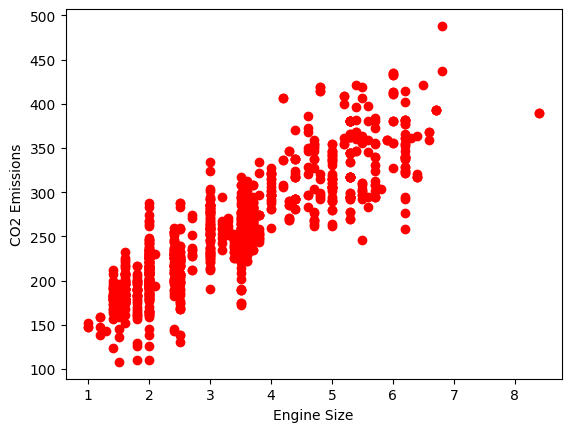

In [7]:
plt.scatter(c_data.ENGINESIZE, c_data.CO2EMISSIONS, color='red')
plt.ylabel('CO2 Emissions')
plt.xlabel('Engine Size')

Text(0.5, 0, 'Cylinder')

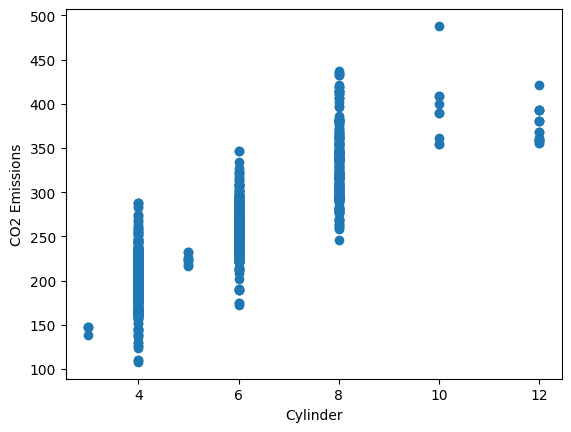

In [8]:
plt.scatter(c_data.CYLINDERS, c_data.CO2EMISSIONS)
plt.ylabel('CO2 Emissions')
plt.xlabel('Cylinder')

# Create Train and Test Data

In [9]:
mask = np.random.rand(len(data)) > 0.8
train = data[~ mask]
test = data[mask]
train, test

(      MODELYEAR   MAKE     MODEL    VEHICLECLASS  ENGINESIZE  CYLINDERS  \
 0          2014  ACURA       ILX         COMPACT         2.0          4   
 1          2014  ACURA       ILX         COMPACT         2.4          4   
 3          2014  ACURA   MDX 4WD     SUV - SMALL         3.5          6   
 4          2014  ACURA   RDX AWD     SUV - SMALL         3.5          6   
 5          2014  ACURA       RLX        MID-SIZE         3.5          6   
 ...         ...    ...       ...             ...         ...        ...   
 1061       2014  VOLVO      XC60     SUV - SMALL         3.2          6   
 1063       2014  VOLVO  XC60 AWD     SUV - SMALL         3.2          6   
 1064       2014  VOLVO  XC70 AWD     SUV - SMALL         3.0          6   
 1065       2014  VOLVO  XC70 AWD     SUV - SMALL         3.2          6   
 1066       2014  VOLVO  XC90 AWD  SUV - STANDARD         3.2          6   
 
      TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
 0          

Text(0.5, 0, 'Engine Size')

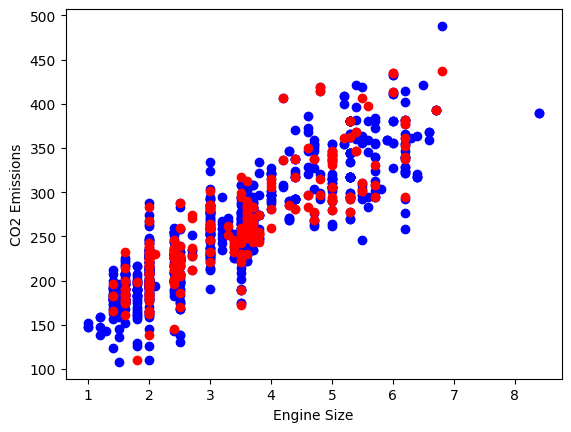

In [85]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
ax.scatter(test.ENGINESIZE, test.CO2EMISSIONS, color='red')
plt.ylabel('CO2 Emissions')
plt.xlabel('Engine Size')

# Modeling

In [10]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
reg.fit(train_x, train_y)
print(f'Coef: {reg.coef_}')
print(f'Intercept: {reg.intercept_}')

Coef: [[39.57602879]]
Intercept: [124.3122236]


## Outputs

Text(0.5, 0, 'Engine Size')

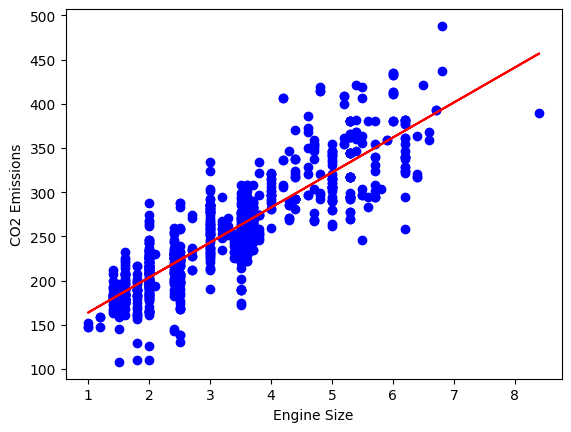

In [11]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color= 'blue')
plt.plot(train_x, reg.coef_[0][0] * train_x + reg.intercept_[0], '-r')
plt.ylabel('CO2 Emissions')
plt.xlabel('Engine Size')

# Evluation

In [12]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = reg.predict(test_x)

print("MAE: %.4f" % np.mean(np.absolute(test_y_ - test_y)))
print("MSE: %.4f" % np.mean((test_y_ - test_y) ** 2))
print("R2: %.4f" % r2_score(test_y , test_y_) )

MAE: 23.3789
MSE: 898.9479
R2: 0.7854


## SELF TEST

In [13]:
reg.predict([[4.2]])

array([[290.5315445]])